# Double Descent: When More Complexity Helps (Again)

**The classical view**: As model complexity increases, test error first decreases (underfitting → good fit), then increases (overfitting).

**The surprising reality**: Test error can decrease *again* as we push complexity far beyond the interpolation threshold.

This notebook demonstrates the **double descent** phenomenon — a counterintuitive behavior observed in modern deep learning that challenges traditional statistical wisdom.

## What We'll Learn

1. **The classical bias-variance tradeoff** — the traditional U-shaped test error curve
2. **The interpolation threshold** — where the model perfectly fits the training data
3. **The second descent** — why adding more parameters can reduce test error even after overfitting
4. **When and why it happens** — the role of implicit regularization and model capacity

By the end, you'll understand one of the most important phenomena explaining why massive neural networks generalize so well.

## Setup

Set random seed for reproducibility.

In [ ]:
from aiml_notebooks import get_device, set_seed

In [2]:
set_seed(42)
device = get_device(prefer_cpu=True)  # Use CPU for stability
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 1. The Data

We'll use a simple 1D regression problem: fitting a noisy sine wave.

This gives us a clear signal (the sine wave) plus noise, making it easy to see when models underfit, overfit, or generalize well.

In [3]:
def generate_data(n_samples=20, noise_level=0.3, seed=42):
    """Generate noisy sine wave data."""
    np.random.seed(seed)
    X = np.linspace(0, 1, n_samples)
    y_true = np.sin(2 * np.pi * X)
    y = y_true + np.random.normal(0, noise_level, n_samples)
    return X.reshape(-1, 1), y, y_true

# Generate training data (small sample to make overfitting easy)
X_train, y_train, y_train_true = generate_data(n_samples=20, noise_level=0.3)

# Generate test data (more samples, same distribution)
X_test, y_test, y_test_true = generate_data(n_samples=100, noise_level=0.3, seed=43)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 20
Test samples: 100


Visualize the data.

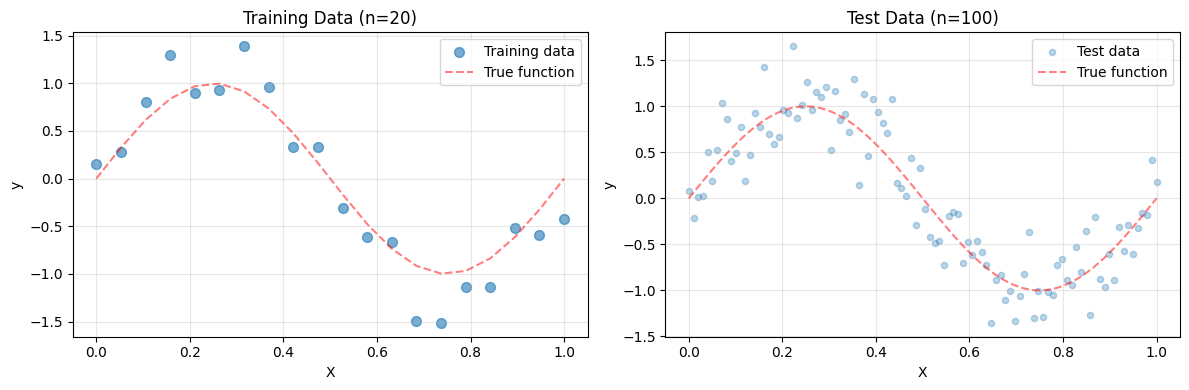

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, s=50, label='Training data')
plt.plot(X_train, y_train_true, 'r--', alpha=0.5, label='True function')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Training Data (n=20)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, alpha=0.3, s=20, label='Test data')
plt.plot(X_test, y_test_true, 'r--', alpha=0.5, label='True function')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Test Data (n=100)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Classical View: The Bias-Variance Tradeoff

Traditional machine learning says: as we increase model complexity, test error follows a **U-shaped curve**.

- **Left side (low complexity)**: High bias, low variance → underfitting
- **Middle (optimal)**: Balanced bias and variance → good generalization
- **Right side (high complexity)**: Low bias, high variance → overfitting

Let's see this with **polynomial regression** of increasing degree.

### Polynomial Regression

A degree-$d$ polynomial has $d+1$ parameters: $y = w_0 + w_1 x + w_2 x^2 + \ldots + w_d x^d$

As $d$ increases, the model can fit more complex functions.

In [ ]:
from sklearn.preprocessing import PolynomialFeaturesfrom sklearn.linear_model import Ridge

In [5]:
def fit_polynomial(X_train, y_train, X_test, y_test, degree, alpha=0.0):
    """Fit polynomial of given degree and return train/test errors."""
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X_train_poly, y_train)
    
    train_error = np.mean((model.predict(X_train_poly) - y_train) ** 2)
    test_error = np.mean((model.predict(X_test_poly) - y_test) ** 2)
    
    return train_error, test_error, model, poly

Try a few different polynomial degrees and visualize the fits.

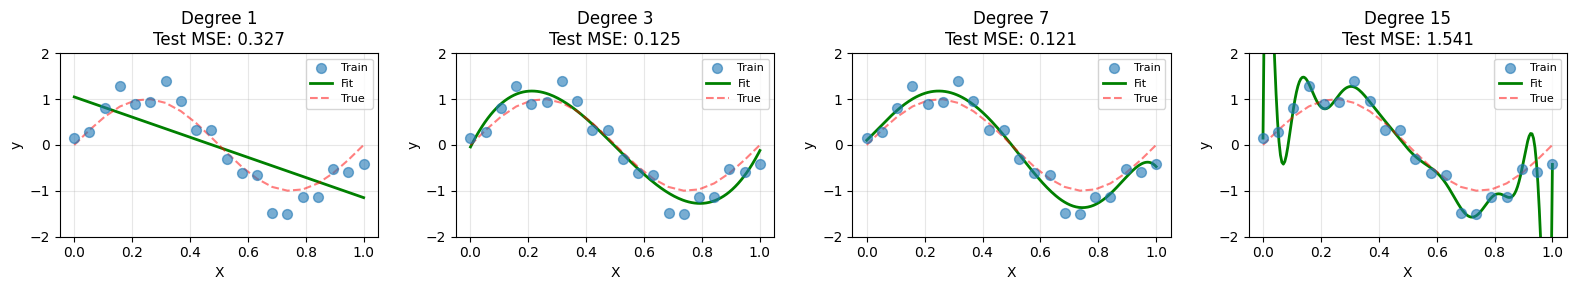

In [6]:
degrees_to_visualize = [1, 3, 7, 15]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for i, degree in enumerate(degrees_to_visualize):
    train_err, test_err, model, poly = fit_polynomial(X_train, y_train, X_test, y_test, degree)
    
    # Generate smooth curve for visualization
    X_vis = np.linspace(0, 1, 200).reshape(-1, 1)
    X_vis_poly = poly.transform(X_vis)
    y_pred = model.predict(X_vis_poly)
    
    axes[i].scatter(X_train, y_train, alpha=0.6, s=50, label='Train', zorder=3)
    axes[i].plot(X_vis, y_pred, 'g-', linewidth=2, label='Fit')
    axes[i].plot(X_train, y_train_true, 'r--', alpha=0.5, label='True')
    axes[i].set_title(f'Degree {degree}\nTest MSE: {test_err:.3f}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('y')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

**Observations**:
- **Degree 1**: Too simple (underfitting) — can't capture the sine wave
- **Degree 3-7**: Good fit — balances complexity and generalization
- **Degree 15**: Overfitting — wiggles through noise points

### The Classical U-Curve

Now let's systematically vary the polynomial degree and plot the **test error curve**.

In [7]:
# Test many polynomial degrees
degrees = range(1, 20)
train_errors = []
test_errors = []

for degree in degrees:
    train_err, test_err, _, _ = fit_polynomial(X_train, y_train, X_test, y_test, degree)
    train_errors.append(train_err)
    test_errors.append(test_err)

print(f"Minimum test error at degree {degrees[np.argmin(test_errors)]}")

Minimum test error at degree 5


/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.45256e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Plot the classic U-shaped curve.

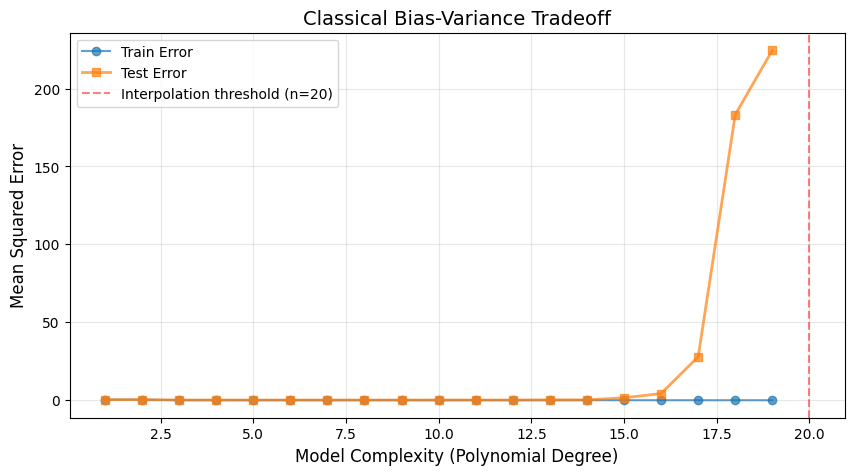

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_errors, 'o-', label='Train Error', alpha=0.7)
plt.plot(degrees, test_errors, 's-', label='Test Error', alpha=0.7, linewidth=2)
plt.axvline(x=len(X_train), color='red', linestyle='--', alpha=0.5, label='Interpolation threshold (n=20)')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Classical Bias-Variance Tradeoff', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key insight**: The test error reaches a minimum around degree 3-5, then increases as we add more parameters.

This is the **classical U-curve** — the foundation of traditional model selection.

## 3. The Interpolation Threshold

Notice the red line at degree 20. This is special: the model has **exactly as many parameters as training samples**.

At this point, the model can **perfectly interpolate** the training data (achieve zero training error).

Classical theory predicts this should give the **worst** test error. But what actually happens?

Let's look closely at what happens **at and beyond** the interpolation threshold.

In [9]:
# Extend to much higher degrees
degrees_extended = list(range(1, 50))
train_errors_ext = []
test_errors_ext = []

for degree in degrees_extended:
    train_err, test_err, _, _ = fit_polynomial(X_train, y_train, X_test, y_test, degree, alpha=1e-10)
    train_errors_ext.append(train_err)
    test_errors_ext.append(test_err)

print(f"Test error at interpolation threshold (degree {len(X_train)}): {test_errors_ext[len(X_train)-1]:.4f}")
print(f"Minimum test error overall at degree {degrees_extended[np.argmin(test_errors_ext)]}: {min(test_errors_ext):.4f}")

Test error at interpolation threshold (degree 20): 0.1341
Minimum test error overall at degree 5: 0.1168


Plot the extended curve to see what happens beyond interpolation.

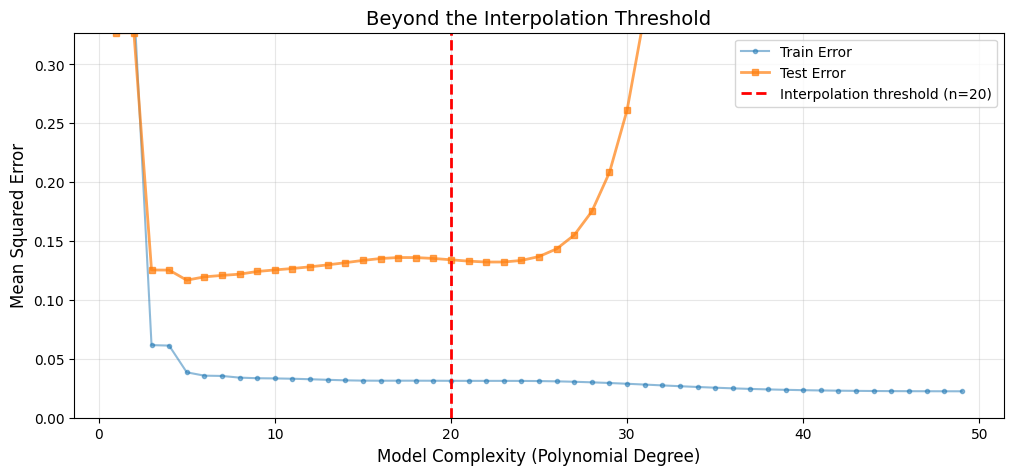

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(degrees_extended, train_errors_ext, 'o-', label='Train Error', alpha=0.5, markersize=3)
plt.plot(degrees_extended, test_errors_ext, 's-', label='Test Error', alpha=0.7, linewidth=2, markersize=4)
plt.axvline(x=len(X_train), color='red', linestyle='--', linewidth=2, label=f'Interpolation threshold (n={len(X_train)})')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Beyond the Interpolation Threshold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, max(test_errors_ext[:30]))
plt.show()

**This is surprising!**

After spiking at the interpolation threshold, the test error **decreases again** as we continue adding parameters.

This is the **double descent** — the test error curve has **two descents**:
1. **First descent**: From underfitting to optimal complexity (classical)
2. **Second descent**: From interpolation threshold to overparameterized regime (modern)

## 4. Double Descent with Neural Networks

Polynomials show the phenomenon clearly, but it's even more pronounced in **neural networks**.

Let's build a simple fully-connected network and vary its width (number of hidden units) to control model capacity.

### Simple MLP for Regression

We'll use a single hidden layer and vary the number of hidden units from very small (underparameterized) to very large (overparameterized).

In [11]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Example: small vs large network
model_small = SimpleMLP(1, 5, 1)
model_large = SimpleMLP(1, 100, 1)

print(f"Small model parameters: {sum(p.numel() for p in model_small.parameters())}")
print(f"Large model parameters: {sum(p.numel() for p in model_large.parameters())}")
print(f"Training samples: {len(X_train)}")

Small model parameters: 16
Large model parameters: 301
Training samples: 20


### Training Function

Train the network with MSE loss and simple SGD.

In [12]:
def train_mlp(model, X_train, y_train, X_test, y_test, epochs=5000, lr=0.01, verbose=False):
    """Train MLP and return final train/test errors."""
    model = model.to(device)
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).reshape(-1, 1).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
        if verbose and (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_t)
        test_pred = model(X_test_t)
        train_error = criterion(train_pred, y_train_t).item()
        test_error = criterion(test_pred, y_test_t).item()
    
    return train_error, test_error, model

### Vary Network Width

Train networks with different hidden layer sizes and observe the double descent.

In [13]:
# Test different hidden sizes
hidden_sizes = [2, 3, 4, 5, 6, 8, 10, 12, 15, 18, 20, 25, 30, 40, 50, 75, 100, 150, 200]
nn_train_errors = []
nn_test_errors = []
nn_param_counts = []

print("Training neural networks with varying widths...")
for i, hidden_size in enumerate(hidden_sizes):
    set_seed(42)  # Same initialization for fair comparison
    model = SimpleMLP(1, hidden_size, 1)
    n_params = sum(p.numel() for p in model.parameters())
    nn_param_counts.append(n_params)
    
    train_err, test_err, _ = train_mlp(model, X_train, y_train, X_test, y_test, epochs=3000, lr=0.01)
    nn_train_errors.append(train_err)
    nn_test_errors.append(test_err)
    
    if (i + 1) % 5 == 0:
        print(f"  [{i+1}/{len(hidden_sizes)}] Hidden={hidden_size}, Params={n_params}, Test Error={test_err:.4f}")

print("\nDone!")
print(f"Interpolation threshold approximately at {len(X_train)} parameters")
print(f"Minimum test error: {min(nn_test_errors):.4f} at {hidden_sizes[np.argmin(nn_test_errors)]} hidden units")

Training neural networks with varying widths...


  [5/19] Hidden=6, Params=19, Test Error=0.2705


  [10/19] Hidden=18, Params=55, Test Error=0.2680


  [15/19] Hidden=50, Params=151, Test Error=0.1248



Done!
Interpolation threshold approximately at 20 parameters
Minimum test error: 0.1194 at 3 hidden units


### The Neural Network Double Descent Curve

Plot test error vs. number of parameters.

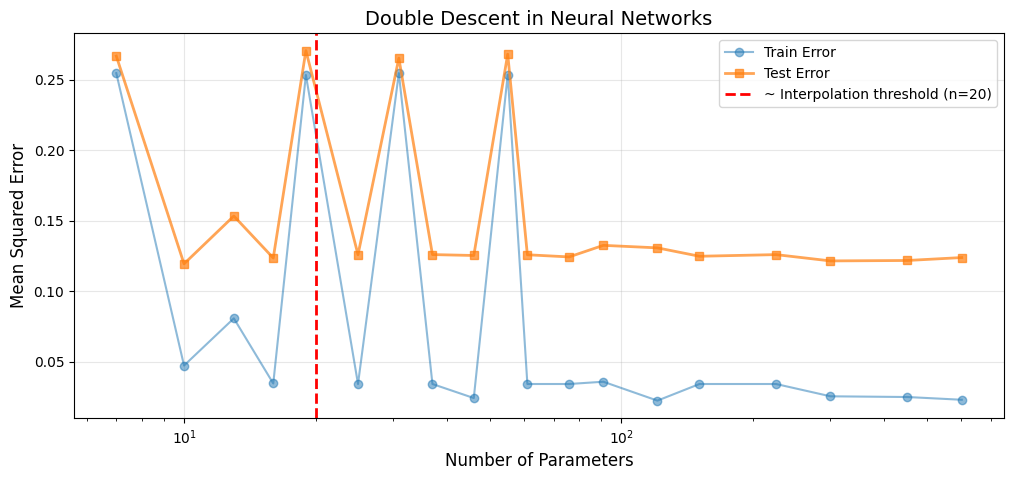

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(nn_param_counts, nn_train_errors, 'o-', label='Train Error', alpha=0.5)
plt.plot(nn_param_counts, nn_test_errors, 's-', label='Test Error', alpha=0.7, linewidth=2)
plt.axvline(x=len(X_train), color='red', linestyle='--', linewidth=2, label=f'~ Interpolation threshold (n={len(X_train)})')
plt.xlabel('Number of Parameters', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Double Descent in Neural Networks', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

**The double descent is clear!**

1. **Underparameterized regime** (left): Classical U-curve — test error decreases then increases
2. **Interpolation threshold** (middle): Peak in test error when params ≈ samples
3. **Overparameterized regime** (right): Second descent — test error decreases again

Modern deep learning operates in the **overparameterized regime** — that's why bigger models often work better!

## 5. Understanding Why: Implicit Regularization

**Why does overparameterization help?**

In the overparameterized regime, there are **many** solutions that perfectly fit the training data. Gradient descent finds a **special** one — typically the solution with the **smallest norm** (implicit regularization).

This "simple" solution tends to generalize better than the complex, wiggly solution found at the interpolation threshold.

### Visualizing Solutions at Different Scales

Let's compare what models learn at three critical points:
1. **Underparameterized**: Too few parameters to fit perfectly
2. **Interpolation threshold**: Just enough to fit, but solution is complex
3. **Overparameterized**: Many parameters, but implicit regularization finds smooth solution

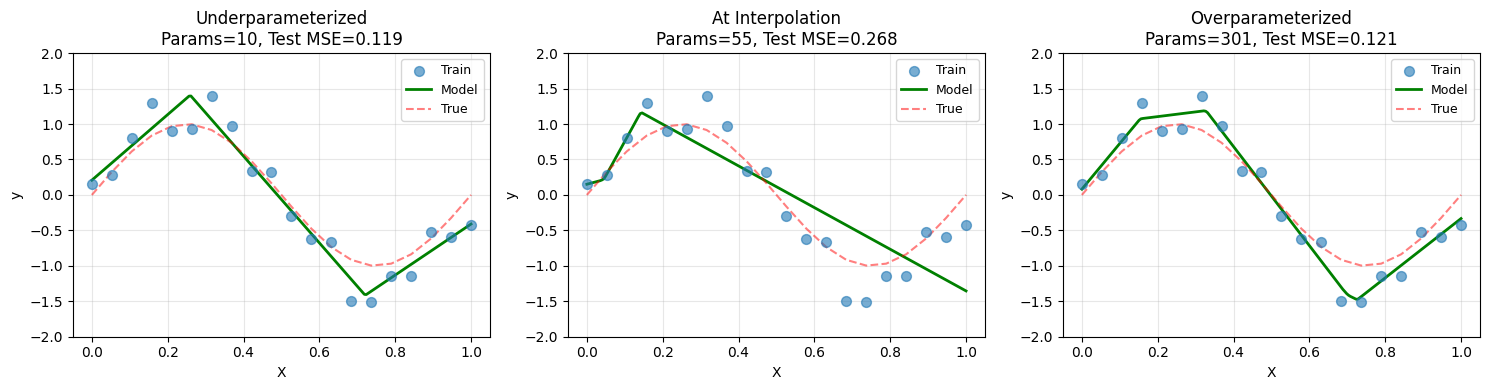

In [15]:
# Train models at three key points
configs = [
    ('Underparameterized', 3),
    ('At Interpolation', 18),
    ('Overparameterized', 100)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, hidden_size) in enumerate(configs):
    set_seed(42)
    model = SimpleMLP(1, hidden_size, 1)
    n_params = sum(p.numel() for p in model.parameters())
    train_err, test_err, trained_model = train_mlp(model, X_train, y_train, X_test, y_test, epochs=3000, lr=0.01)
    
    # Generate predictions
    X_vis = np.linspace(0, 1, 200).reshape(-1, 1)
    X_vis_t = torch.FloatTensor(X_vis).to(device)
    trained_model.eval()
    with torch.no_grad():
        y_pred = trained_model(X_vis_t).cpu().numpy()
    
    axes[i].scatter(X_train, y_train, alpha=0.6, s=50, label='Train', zorder=3)
    axes[i].plot(X_vis, y_pred, 'g-', linewidth=2, label='Model')
    axes[i].plot(X_train, y_train_true, 'r--', alpha=0.5, label='True')
    axes[i].set_title(f'{name}\nParams={n_params}, Test MSE={test_err:.3f}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('y')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

**Key observations**:
- **Underparameterized**: Smooth but doesn't fit training data well
- **At interpolation**: Fits training data perfectly but with complex, wiggly curve (poor generalization)
- **Overparameterized**: Also fits training data well but with smoother curve (better generalization)

The overparameterized model has more capacity, but gradient descent's implicit bias toward simple solutions makes it generalize better!

## 6. Factors Affecting Double Descent

The shape and strength of double descent depends on several factors:
1. **Training data size**: More data pushes the interpolation threshold to the right
2. **Noise level**: More noise makes the peak sharper
3. **Regularization**: Explicit regularization can smooth out the peak

Let's explore these effects.

### Effect of Training Sample Size

With more training data, we need more parameters to reach the interpolation threshold.

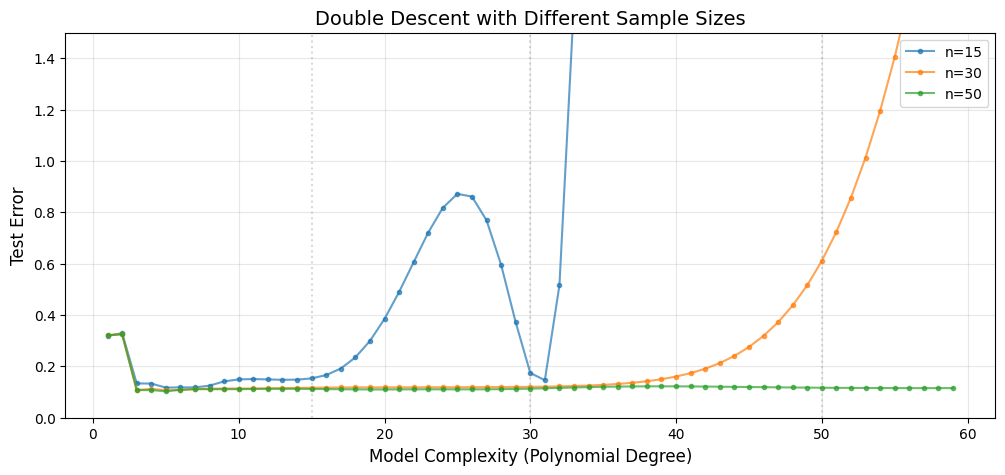

In [16]:
# Compare different sample sizes
sample_sizes = [15, 30, 50]
degrees_range = range(1, 60)

plt.figure(figsize=(12, 5))

for n_samples in sample_sizes:
    X_tr, y_tr, _ = generate_data(n_samples=n_samples, noise_level=0.3, seed=42)
    test_errs = []
    
    for degree in degrees_range:
        _, test_err, _, _ = fit_polynomial(X_tr, y_tr, X_test, y_test, degree, alpha=1e-10)
        test_errs.append(test_err)
    
    plt.plot(degrees_range, test_errs, 'o-', label=f'n={n_samples}', alpha=0.7, markersize=3)
    plt.axvline(x=n_samples, color='gray', linestyle=':', alpha=0.3)

plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Test Error', fontsize=12)
plt.title('Double Descent with Different Sample Sizes', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.5)
plt.show()

**Observation**: The interpolation threshold (peak) moves **right** as we add more training data.

This makes intuitive sense: with more data points, we need more parameters to perfectly interpolate them all.

### Effect of Noise Level

Higher noise makes fitting harder and can create a sharper peak at the interpolation threshold.

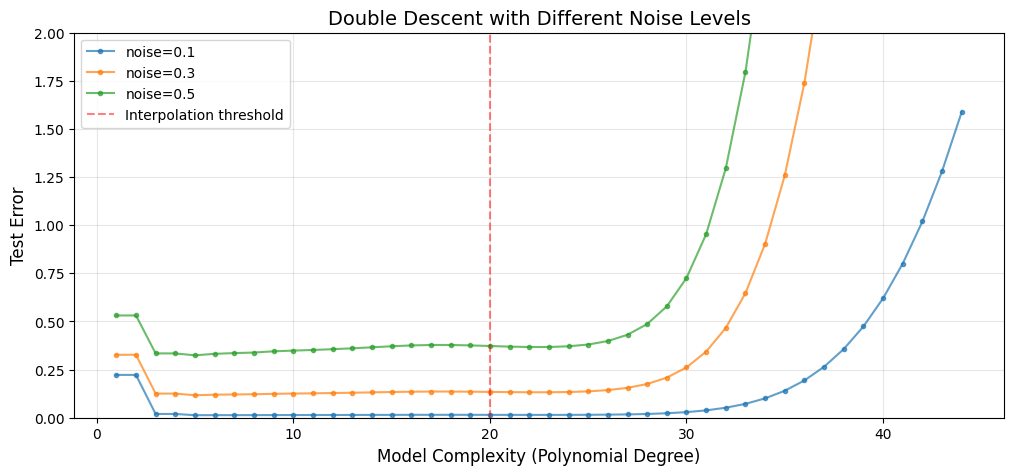

In [17]:
# Compare different noise levels
noise_levels = [0.1, 0.3, 0.5]
n_samples = 20
degrees_range = range(1, 45)

plt.figure(figsize=(12, 5))

for noise in noise_levels:
    X_tr, y_tr, _ = generate_data(n_samples=n_samples, noise_level=noise, seed=42)
    X_te, y_te, _ = generate_data(n_samples=100, noise_level=noise, seed=43)
    test_errs = []
    
    for degree in degrees_range:
        _, test_err, _, _ = fit_polynomial(X_tr, y_tr, X_te, y_te, degree, alpha=1e-10)
        test_errs.append(test_err)
    
    plt.plot(degrees_range, test_errs, 'o-', label=f'noise={noise}', alpha=0.7, markersize=3)

plt.axvline(x=n_samples, color='red', linestyle='--', alpha=0.5, label='Interpolation threshold')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Test Error', fontsize=12)
plt.title('Double Descent with Different Noise Levels', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 2)
plt.show()

**Observation**: Higher noise leads to:
1. Higher overall test error (makes sense — harder problem)
2. More pronounced peak at interpolation threshold
3. Still shows double descent, but second descent may not reach as low as low-noise case

### Effect of Regularization

Explicit regularization (like L2 penalty) can smooth the interpolation peak.

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.45256e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.p

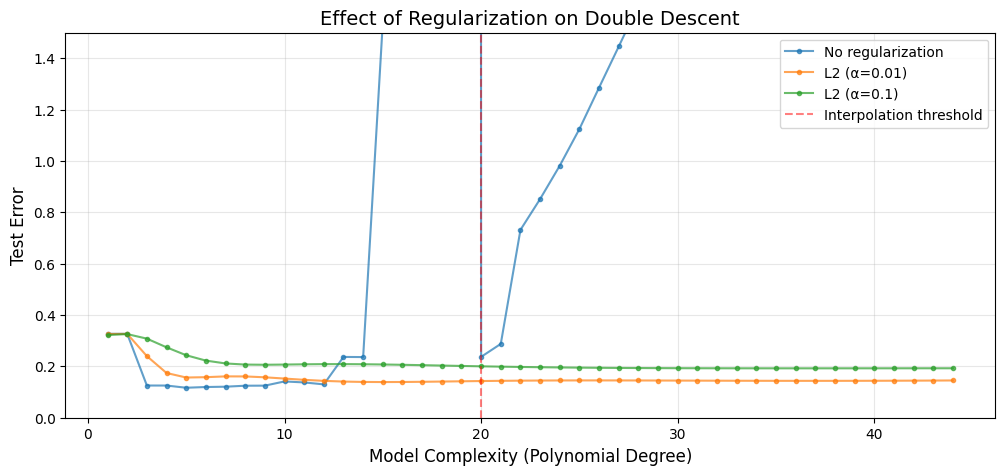

In [18]:
# Compare different regularization strengths
alphas = [0.0, 0.01, 0.1]
n_samples = 20
degrees_range = range(1, 45)

X_tr, y_tr, _ = generate_data(n_samples=n_samples, noise_level=0.3, seed=42)

plt.figure(figsize=(12, 5))

for alpha in alphas:
    test_errs = []
    
    for degree in degrees_range:
        _, test_err, _, _ = fit_polynomial(X_tr, y_tr, X_test, y_test, degree, alpha=alpha)
        test_errs.append(test_err)
    
    label = 'No regularization' if alpha == 0.0 else f'L2 (α={alpha})'
    plt.plot(degrees_range, test_errs, 'o-', label=label, alpha=0.7, markersize=3)

plt.axvline(x=n_samples, color='red', linestyle='--', alpha=0.5, label='Interpolation threshold')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Test Error', fontsize=12)
plt.title('Effect of Regularization on Double Descent', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.5)
plt.show()

**Observation**: Regularization **smooths the peak** at the interpolation threshold.

With strong regularization, the double descent curve becomes more like a monotonic decrease — the peak is suppressed because regularization prevents the model from fitting noise too aggressively.

## 7. Key Takeaways

### The Double Descent Phenomenon

**Classical wisdom**: Test error vs. model complexity follows a U-curve (bias-variance tradeoff).

**Modern reality**: Test error can have **two descents**:
1. **First descent**: Underparameterized → optimal (classical regime)
2. **Peak**: At the interpolation threshold (params ≈ samples)
3. **Second descent**: Overparameterized regime (modern deep learning)

### Why It Matters

- **Modern deep learning lives in the overparameterized regime** — models with millions/billions of parameters trained on thousands/millions of samples
- **"Bigger is better"** often holds: more parameters can improve generalization, even when already overfitting
- **Implicit regularization** from gradient descent is key: it finds simple solutions among many that fit the training data

### Practical Implications

1. **Don't fear overparameterization**: If your model has way more parameters than training samples, that's often fine (even good!)
2. **Watch for the interpolation threshold**: The worst generalization often happens when params ≈ samples
3. **Regularization helps**: Both explicit (L2, dropout) and implicit (SGD, architecture) regularization smooth the double descent curve
4. **More data shifts the curve**: With more training data, you need more parameters to reach the dangerous interpolation zone

### Visualizing the Full Picture

Let's create one final visualization summarizing the three regimes.

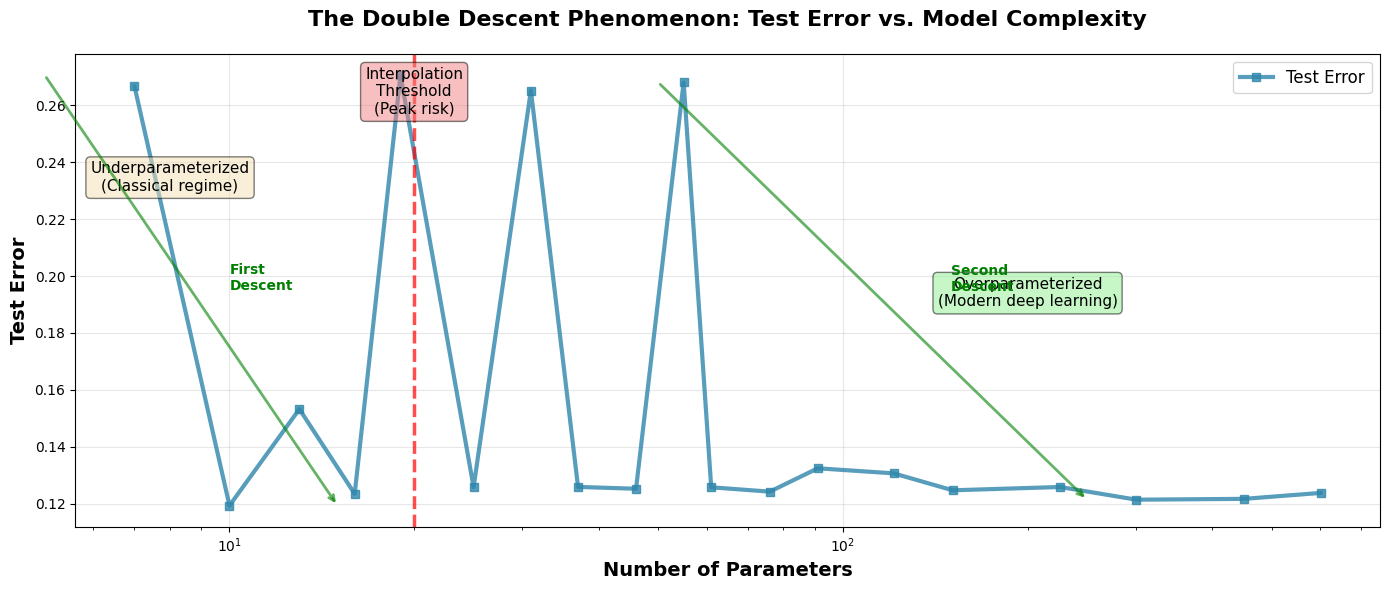

In [19]:
# Create an annotated double descent curve
fig, ax = plt.subplots(figsize=(14, 6))

# Use our neural network results
ax.plot(nn_param_counts, nn_test_errors, 's-', label='Test Error', alpha=0.8, linewidth=3, markersize=6, color='#2E86AB')
ax.axvline(x=len(X_train), color='red', linestyle='--', linewidth=2.5, alpha=0.7)

# Annotate regions
ax.text(8, max(nn_test_errors) * 0.85, 'Underparameterized\n(Classical regime)', 
        ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(len(X_train), max(nn_test_errors) * 0.95, 'Interpolation\nThreshold\n(Peak risk)', 
        ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax.text(200, max(nn_test_errors) * 0.7, 'Overparameterized\n(Modern deep learning)', 
        ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Arrows for descents
ax.annotate('', xy=(15, min(nn_test_errors[:10])), xytext=(5, max(nn_test_errors[:5])),
            arrowprops=dict(arrowstyle='->', lw=2, color='green', alpha=0.6))
ax.text(10, (min(nn_test_errors[:10]) + max(nn_test_errors[:5])) / 2, 'First\nDescent', 
        fontsize=10, color='green', weight='bold')

ax.annotate('', xy=(250, min(nn_test_errors[-5:])), xytext=(50, max(nn_test_errors[8:13])),
            arrowprops=dict(arrowstyle='->', lw=2, color='green', alpha=0.6))
ax.text(150, (min(nn_test_errors[-5:]) + max(nn_test_errors[8:13])) / 2, 'Second\nDescent', 
        fontsize=10, color='green', weight='bold')

ax.set_xlabel('Number of Parameters', fontsize=14, weight='bold')
ax.set_ylabel('Test Error', fontsize=14, weight='bold')
ax.set_title('The Double Descent Phenomenon: Test Error vs. Model Complexity', fontsize=16, weight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Further Exploration

Double descent appears in many contexts:
- **Sample-wise double descent**: Varying number of training samples (not model size)
- **Epoch-wise double descent**: Test error vs. training time
- **Different architectures**: CNNs, Transformers, ResNets all show variants

This phenomenon is fundamental to understanding modern deep learning and why techniques that seem to "break" classical statistical rules actually work so well in practice!